# Factor Analysis

This notebook will examine some of the variables that are going to be used as signals. Before generating signals for these portfolios they should be tested amongst the tradable securities to examine their factor exposure. Therefore this notebook will examine how the different ways the signals influence the returns. 

In [1]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import statsmodels.api as sm

from   matplotlib import cm
import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

In [2]:
note_path = os.getcwd()
repo_path = os.path.abspath(os.path.join(note_path, ".."))
src_path  = os.path.join(repo_path, "src")
data_path = os.path.join(repo_path, "data")
prep_path = os.path.join(data_path, "PrepData")
fact_path = os.path.join(data_path, "FactorExposure")
pic_path  = os.path.join(repo_path, "writeup", "pictures")

In [3]:
sys.path.append(src_path)
from FactorExposure import FactorExposure

In [4]:
path      = os.path.join(data_path, "FXTickerGuide.xlsx")
df_ticker = (pd
    .read_excel(io = path, sheet_name = "TickerGuide")
    .rename(columns = {
        "ticker"       : "fx_ticker",
        "etf_benchmark": "index_ticker"})
    .drop(columns = ["Active", "FACTOR_ACTIVE"])
    .assign(etf_ticker = lambda x: x.etf_ticker.str.split(" ").str[0])
    .assign(fx_name = lambda x: x.shorthand_name + " " + x.return_type.str.capitalize()))

In [5]:
FX_RENAMER = (df_ticker
    .set_index("fx_ticker")
    .fx_name
    .to_dict())

vol_renamer = {
    "lag_rtn" : "Lagged",
    "perf_rtn": "Perfect",
    "px_rtn"  : "None"}

param_renamer = {
    "param_val" : "Coef",
    "pvalue"    : r"$p$-value",
    "tvalue"    : r"$t$-value",
    "r2"        : r"$R^2$"}

group_renamer = {
    'em_carry'       : "EM Carry", 
    'g10_carry'      : "G10 Carry", 
    'liquid_future'  : "Liquid Futures", 
    'illiquid_future': "Illiquid Futures"}

RENAMER = {**FX_RENAMER, **vol_renamer, **param_renamer, **group_renamer}

In [6]:
fx_country_mapper = (df_ticker[
    ["fx_ticker", "country"]]
    .set_index("fx_ticker")
    .country
    .to_dict())

FLOAT_FORMAT = lambda x: f"{x:.2f}"

# Comparing Sovereign Equity Returns with FX Returns

In this section start by comparing the sovereing equity returns with the FX returns. The idea is to start with the raw equity returns to set a baseline model and then compare the equity returns differential. The overall interest is in the following
1. Examining if the factors are statistically significant
2. Examining the relationship between the equity returns and their FX counterparts

In [7]:
path = os.path.join(fact_path, "ReturnsOLSModels.pkl")
with open(path, "rb") as f: rtn_models = pickle.load(f)

In [8]:
df_rtn_params = FactorExposure().get_ols_params(rtn_models)

In [9]:
df_rtn_param_prep = (df_rtn_params
    .assign(
        str_string = lambda x: x.group_var.str.split("-"),
        etf_ticker = lambda x: x.str_string.str[0],
        fx_ticker  = lambda x: x.str_string.str[1],
        vol_target = lambda x: x.str_string.str[2])
    .drop(columns = ["str_string", "group_var"]))

df_rtn_beta = (df_rtn_param_prep
    .loc[lambda x: x.param_name == "etf_rtn"]
    .drop(columns = ["param_name"])
    .melt(id_vars = ["etf_ticker", "fx_ticker", "vol_target"]))

In [10]:
display(df_rtn_beta
    .assign(country = lambda x: x.fx_ticker.map(fx_country_mapper))
    .replace(RENAMER)
    .rename(columns = {
        "etf_ticker": "ETF",
        "fx_ticker" : "FX",
        "variable"  : "",
        "vol_target": "Vol. Target",
        "country"   : "Country"})
    .pivot(index = ["ETF", "Country", "FX"], columns = ["", "Vol. Target"], values = "value"))

Coef                          $p$-value  \
Vol. Target                     Lagged   Perfect      None         Lagged   
ETF  Country      FX                                                        
ARGT Argentina    ARS Carry   0.101849  0.105214  0.082595   7.548933e-11   
COLO Colombia     COP Carry   0.607601  0.612101  0.321565   0.000000e+00   
ECH  Chile        CLP Carry   0.611804  0.617712  0.269471   0.000000e+00   
EDEN Denmark      DKK Carry   0.341631  0.351876  0.145107   9.574851e-98   
EIDO Indonesia    IDR Carry   0.314555  0.318034  0.072750   5.437610e-88   
EIS  Israel       ISR Future  0.506367  0.513330  0.198298  6.232239e-288   
ENOR Norway       NOK Carry   0.675068  0.675460  0.335389   0.000000e+00   
                  NOK Future  0.660479  0.663634  0.326852   0.000000e+00   
ENZL New Zealand  NZD Carry   0.683346  0.689257  0.361125   0.000000e+00   
                  NZD Future  0.659743  0.668783  0.354008   0.000000e+00   
EPHE Philippines  PHP Carry   0.247601  0.250208  0.051285   7.695537e-56   
EPOL Poland       PLN Carry   0.655118  0.660935  0.291538   0.000000e+00   
                  PLN Future  0.638348  0.645011  0.286513   0.000000e+00   
EPU  Peru         PEN Carry   0.408195  0.397504  0.094871  1.986273e-163   
EWA  Australia    AUD Carry   0.626709  0.631803  0.303772   0.000000e+00   
                  AUD Future  0.588333  0.595381  0.277878   0.000000e+00   
EWC  Canada       CAD Carry   0.579834  0.589358  0.225581   0.000000e+00   
                  CAD Future  0.539584  0.551124  0.205662   0.000000e+00   
EWD  Sweden       SEK Carry   0.470199  0.478611  0.198889   0.000000e+00   
                  SEK Future  0.507304  0.512513  0.210591   0.000000e+00   
EWH  Hong Kong    HKD Carry   0.101528  0.098934  0.001376   9.745203e-18   
EWJ  Japan        JPY Carry   0.022288  0.028840  0.027247   5.430419e-02   
                  JPY Future  0.034192  0.038730  0.040858   3.118741e-03   
EWL  Switzerland  CHF Carry   0.272428  0.284813  0.126456  4.351381e-129   
                  CHF Future  0.270471  0.281075  0.128382  3.890286e-128   
EWM  Malaysia     MYR Carry   0.278854  0.282544  0.055701   4.053017e-44   
EWS  Singapore    SGD Carry   0.454728  0.459867  0.086144   0.000000e+00   
EWT  Taiwan       TWD Carry   0.279014  0.275284  0.034209  1.090218e-107   
EWU  UK           GBP Carry   0.397074  0.398586  0.163831  8.514094e-280   
                  GBP Future  0.380652  0.383962  0.155778  1.118275e-258   
EWW  Mexico       MXN Carry   0.680267  0.678136  0.272863   0.000000e+00   
                  MXN Future  0.637485  0.636404  0.243375   0.000000e+00   
EWY  Korea        KRW Carry   0.374342  0.372826  0.112106  2.022629e-208   
                  KRW Future  0.587632  0.588867  0.191638   0.000000e+00   
EWZ  Brazil       BRL Carry   0.726161  0.724754  0.309207   0.000000e+00   
                  BRL Future  0.681382  0.682795  0.284512   0.000000e+00   
EZA  South Africa ZAR Carry   0.729761  0.742539  0.370722   0.000000e+00   
EZU  Euro         EUR Carry   0.376515  0.392741  0.151981  4.499313e-219   
                  EUR Future  0.364563  0.380631  0.144419  7.456938e-207   
GLCR Iceland      ISK Carry   0.411375  0.434747  0.155909   1.304232e-10   
INDA India        INR Carry   0.382869  0.385360  0.109518  5.649249e-127   
                  INR Future  0.569045  0.574812  0.165117  6.010177e-280   
MCHI China        CNY Carry   0.224493  0.223868  0.034573   4.017831e-44   
                  CNY Future -0.214985 -0.212738 -0.036809   1.389648e-34   
THD  Thailand     THB Carry   0.345423  0.352643  0.063793  2.192767e-126   
TUR  Turkey       TRY Carry   0.650008  0.640831  0.278913   0.000000e+00   

                                                            $t$-value  \
Vol. Target                         Perfect           None     Lagged   
ETF  Country      FX                                                    
ARGT Argentina    ARS Carry    5.250546e-

# Comparing Sovereign Equity Returns Differential to FX Returns

Now the next section is to take the returns differential between the ETFs returns vs the SPY returns, and run the same regression. 

In [11]:
path = os.path.join(fact_path, "ReturnsDifferentialOLSModels.pkl")
with open(path, "rb") as f: spread_models = pickle.load(f)

In [12]:
df_spread_params = FactorExposure().get_ols_params(spread_models)

In [13]:
df_spread_param_prep = (df_spread_params
    .assign(
        str_string = lambda x: x.group_var.str.split("-"),
        etf_ticker = lambda x: x.str_string.str[0],
        fx_ticker  = lambda x: x.str_string.str[1],
        vol_target = lambda x: x.str_string.str[2])
    .drop(columns = ["str_string", "group_var"]))

df_spread_beta = (df_spread_param_prep
    .loc[lambda x: x.param_name == "spread"]
    .drop(columns = ["param_name"])
    .melt(id_vars = ["etf_ticker", "fx_ticker", "vol_target"]))

In [14]:
display(df_spread_beta
    .assign(country = lambda x: x.fx_ticker.map(fx_country_mapper))
    .replace(RENAMER)
    .rename(columns = {
        "etf_ticker": "ETF",
        "fx_ticker" : "FX",
        "variable"  : "",
        "vol_target": "Vol. Target",
        "country"   : "Country"})
    .pivot(index = ["ETF", "Country", "FX"], columns = ["", "Vol. Target"], values = "value"))

Coef                          $p$-value  \
Vol. Target                     Lagged   Perfect      None         Lagged   
ETF  Country      FX                                                        
ARGT Argentina    ARS Carry   0.080743  0.083306  0.125669   2.649483e-06   
COLO Colombia     COP Carry   0.321077  0.321118  0.272432  6.565494e-100   
ECH  Chile        CLP Carry   0.364574  0.366696  0.257177  1.287486e-126   
EDEN Denmark      DKK Carry   0.326825  0.331011  0.169822   7.054077e-70   
EIDO Indonesia    IDR Carry   0.203905  0.206571  0.085922   4.402108e-34   
EIS  Israel       ISR Future  0.371592  0.372360  0.227051   7.651987e-83   
ENOR Norway       NOK Carry   0.469580  0.468869  0.372797  4.618324e-141   
                  NOK Future  0.485049  0.484924  0.381957  5.501835e-152   
ENZL New Zealand  NZD Carry   0.368666  0.375285  0.279014  1.646628e-115   
                  NZD Future  0.395259  0.401801  0.297142  8.885259e-135   
EPHE Philippines  PHP Carry   0.177013  0.176129  0.054049   9.045571e-28   
EPOL Poland       PLN Carry   0.471540  0.476240  0.358221  6.026790e-171   
                  PLN Future  0.470905  0.475939  0.358882  8.916526e-175   
EPU  Peru         PEN Carry   0.165405  0.155399  0.072596   1.764648e-25   
EWA  Australia    AUD Carry   0.401071  0.403268  0.306839  2.235509e-214   
                  AUD Future  0.417389  0.418436  0.303622  5.506011e-236   
EWC  Canada       CAD Carry   0.331330  0.338118  0.169995  1.202645e-131   
                  CAD Future  0.383922  0.393078  0.191609  4.045114e-180   
EWD  Sweden       SEK Carry   0.445865  0.454682  0.266320  8.396547e-250   
                  SEK Future  0.575390  0.579671  0.348897  1.338567e-264   
EWH  Hong Kong    HKD Carry   0.050090  0.045946  0.000898   1.556709e-04   
EWJ  Japan        JPY Carry   0.313510  0.318604  0.177708  1.511005e-124   
                  JPY Future  0.304095  0.308328  0.182457  2.300104e-117   
EWL  Switzerland  CHF Carry   0.489434  0.491429  0.256827   0.000000e+00   
                  CHF Future  0.471828  0.475004  0.250482   0.000000e+00   
EWM  Malaysia     MYR Carry   0.196339  0.194019  0.041133   2.697244e-21   
EWS  Singapore    SGD Carry   0.297749  0.296174  0.072930   6.472307e-96   
EWT  Taiwan       TWD Carry   0.287855  0.281734  0.045385   5.254807e-79   
EWU  UK           GBP Carry   0.449646  0.448543  0.236468  2.889150e-221   
                  GBP Future  0.446158  0.446509  0.232764  6.204642e-221   
EWW  Mexico       MXN Carry   0.308616  0.305571  0.261883  2.442909e-105   
                  MXN Future  0.313190  0.307656  0.246884  1.509161e-130   
EWY  Korea        KRW Carry   0.391747  0.393966  0.166704  2.435653e-156   
                  KRW Future  0.488147  0.500508  0.282880  2.796519e-168   
EWZ  Brazil       BRL Carry   0.424700  0.427124  0.365392  5.533413e-231   
                  BRL Future  0.424006  0.427682  0.343103  1.053469e-232   
EZA  South Africa ZAR Carry   0.450221  0.469091  0.464624  3.171222e-214   
EZU  Euro         EUR Carry   0.656843  0.680982  0.346810  4.951116e-308   
                  EUR Future  0.653522  0.679467  0.339314  1.863184e-309   
GLCR Iceland      ISK Carry   0.326999  0.335530  0.155230   5.925950e-07   
INDA India        INR Carry   0.312841  0.317214  0.132569   4.943222e-72   
                  INR Future  0.330009  0.338157  0.163848   2.940524e-72   
MCHI China        CNY Carry   0.174651  0.173607  0.035008   1.310997e-23   
                  CNY Future -0.173719 -0.170181 -0.039826   8.723511e-21   
THD  Thailand     THB Carry   0.275744  0.279027  0.083792   2.311601e-67   
TUR  Turkey       TRY Carry   0.330443  0.322760  0.299905  2.557139e-126   

                                                            $t$-value  \
Vol. Target                         Perfect           None     Lagged   
ETF  Country      FX                                                    
ARGT Argentina    ARS Carry    2.443279e-

# Combining the ETF Returns and ETF Returns Differential

In [15]:
fx_path   = os.path.join(prep_path, "FXVolTargetedReturns.parquet")
etf_path  = os.path.join(prep_path, "ETFVolTargetedReturns.parquet")
tick_path = os.path.join(data_path, "FXTickerGuide.xlsx")

In [16]:
df_eq = (pd
    .read_parquet(path = etf_path, engine = "pyarrow")
    .drop(columns = ["PX_LAST", "vol"])
    .melt(id_vars = ["date", "ticker"])
    .pivot(index = ["date", "variable"], columns = "ticker", values = "value")
    .reset_index()
    .melt(id_vars = ["date", "variable", "SPY"])
    .dropna()
    .assign(spread = lambda x: x.value - x.SPY)
    .drop(columns = ["SPY"])
    .rename(columns = {
        "value" : "etf_rtn",
        "ticker": "etf_ticker"})
    .merge(right = df_ticker, how = "inner", on = ["etf_ticker"]))

In [17]:
df_corr = (df_eq
    [["variable", "etf_ticker", "etf_rtn", "spread", "date"]]
    .drop_duplicates()
    .drop(columns = ["date"])
    .groupby(["variable", "etf_ticker"])
    .agg("corr")
    .loc[lambda x: x.spread != 1]
    .drop(columns = ["etf_rtn"])
    .reset_index()
    .drop(columns = ["level_2"])
    .rename(columns = {"variable": ""})
    .pivot(index = "etf_ticker", columns = "", values = "spread")
    .sort_values("px_rtn"))

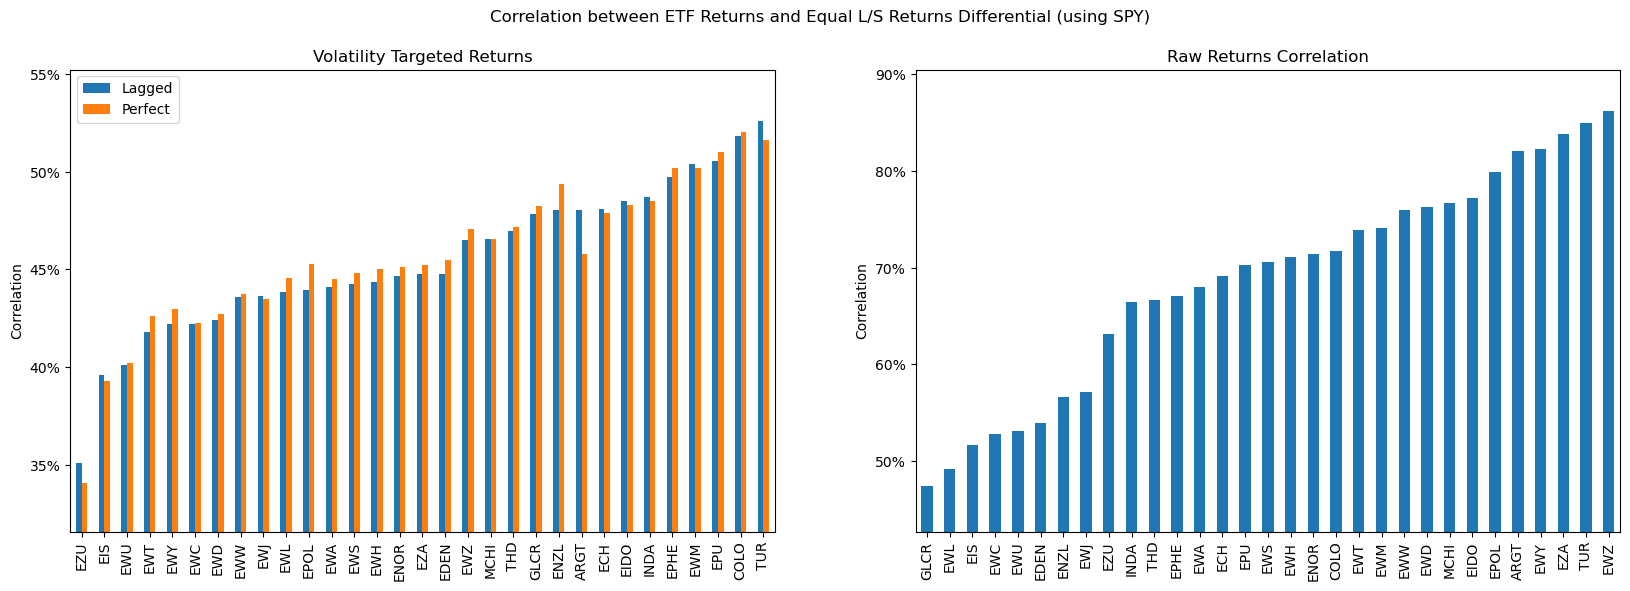

In [18]:
fig, axes = plt.subplots(ncols = 2, figsize = (20,6))
(df_corr
    .drop(columns = ["px_rtn"])
    .sort_values("lag_rtn")
    .rename(columns = RENAMER)
    .plot(
        kind   = "bar", 
        ax     = axes[0],
        ylim   = df_corr.lag_rtn.min() * 0.9,
        xlabel = "",
        title  = "Volatility Targeted Returns"))

(df_corr
    [["px_rtn"]]
    .sort_values("px_rtn")
    .plot(
        kind   = "bar", 
        ax     = axes[1],
        ylim   = df_corr.px_rtn.min() * 0.9,
        xlabel = "",
        legend = False,
        title  = "Raw Returns Correlation"))

fig.suptitle("Correlation between ETF Returns and Equal L/S Returns Differential (using SPY)")
for ax in axes.flatten():
    ax.set_ylabel("Correlation")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x:.0%}"))

In [19]:
path = os.path.join(fact_path, "ReturnsandReturnsDifferentialOLSModels.pkl")
with open(path, "rb") as f: both_models = pickle.load(f)

In [20]:
df_spread_params = FactorExposure().get_ols_params(both_models)

In [21]:
df_param_prep = (df_spread_params
    .assign(
        str_string = lambda x: x.group_var.str.split("-"),
        etf_ticker = lambda x: x.str_string.str[0],
        fx_ticker  = lambda x: x.str_string.str[1],
        vol_target = lambda x: x.str_string.str[2])
    .drop(columns = ["str_string", "group_var"]))

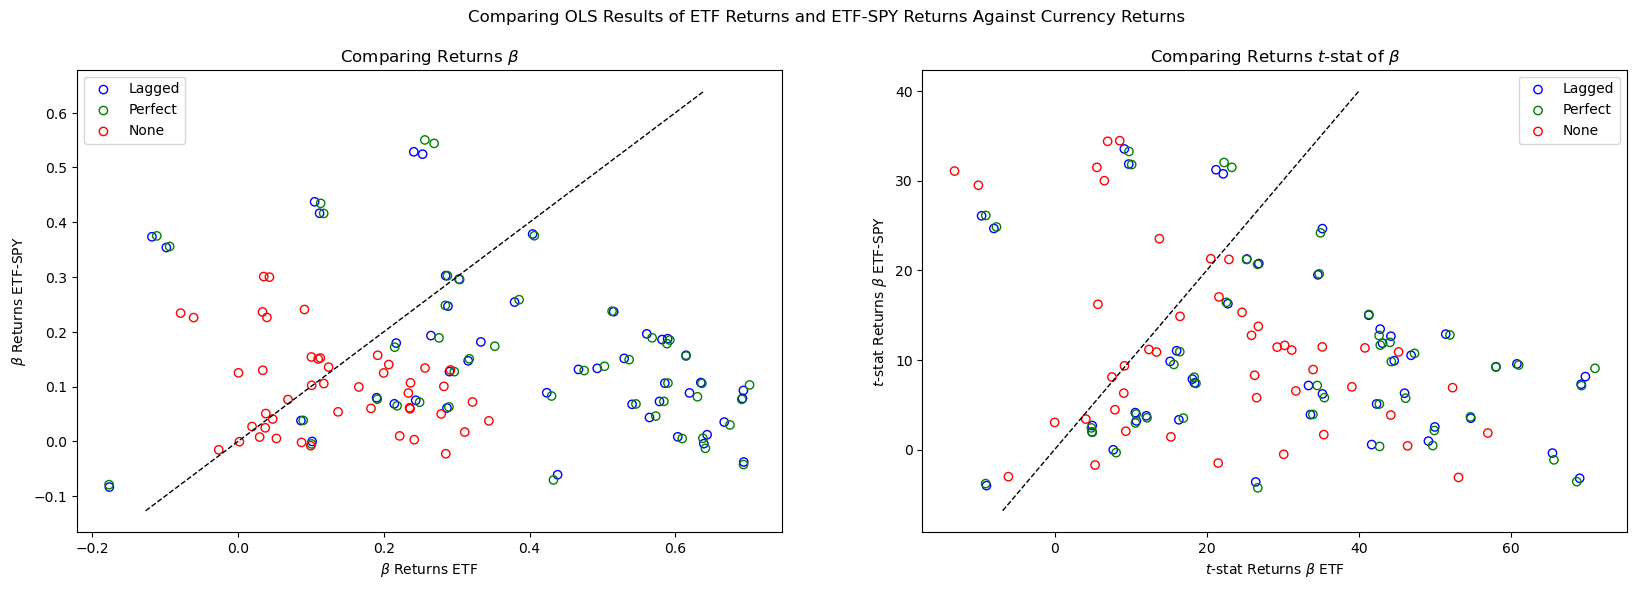

In [22]:
fig, axes   = plt.subplots(ncols = 2, figsize = (20,6))
vol_targets = df_param_prep.vol_target.drop_duplicates().sort_values().to_list()
colors      = ["blue", "green", "red"]

for vol_target, color in zip(vol_targets, colors): 
    
    df_plot_tmp = (df_param_prep
        .loc[lambda x: (x.vol_target == vol_target) & (x.param_name != "const")])

    df_plot1 = (df_plot_tmp
        .drop(columns = ["pvalue", "tvalue", "vol_target"])
        .pivot(index = ["etf_ticker", "fx_ticker"], columns = "param_name", values = "param_val"))

    df_plot2 = (df_plot_tmp
        .drop(columns = ["pvalue", "param_val", "vol_target"])
        .pivot(index = ["etf_ticker", "fx_ticker"], columns = "param_name", values = "tvalue"))

    axes[0].scatter(
        x     = df_plot1["etf_rtn"],
        y     = df_plot1["spread"],
        edgecolors = color,
        facecolors = "none",
        label = RENAMER[vol_target])

    axes[1].scatter(
        x     = df_plot2["etf_rtn"],
        y     = df_plot2["spread"],
        edgecolors = color,
        facecolors = "none",
        label = RENAMER[vol_target])

    axes[0].legend()
    axes[1].legend()

for ax in axes:

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Range where y = x is actually inside both axes
    lower = max(xlim[0] * 0.9, ylim[0] * 1.1)
    upper = min(xlim[1] * 0.9, ylim[1] * 1.1)

    x = np.linspace(lower, upper, 500)
    # y = x
    ax.plot(
        x,
        x,
        color="black",
        linestyle="--",
        linewidth=1,
        zorder=1
    )


axes[0].set_xlabel(r"$\beta$ Returns ETF")
axes[0].set_ylabel(r"$\beta$ Returns ETF-SPY")
axes[0].set_title(r"Comparing Returns $\beta$")

axes[1].set_xlabel(r"$t$-stat Returns $\beta$ ETF")
axes[1].set_ylabel(r"$t$-stat Returns $\beta$ ETF-SPY")
axes[1].set_title(r"Comparing Returns $t$-stat of $\beta$")

fig.suptitle("Comparing OLS Results of ETF Returns and ETF-SPY Returns Against Currency Returns")
plt.show()

In [23]:
path = os.path.join(fact_path, "PCAOLSModels.pkl")
with open(path, "rb") as f: pca_models = pickle.load(f)

In [24]:
df_pca_params = FactorExposure().get_ols_params(pca_models)

In [25]:
plot_renamer = {
    "param_val": r"Comparing Returns $\beta$",
    "tvalue"   : r"Copmaring Returns $t$-stat of $\beta$"}

x_renamer = {
    "param_val": r"$\beta$ Returns ETF",
    "tvalue"   : r"$t$-stat Returns $\beta$ ETF"}

y_renamer = {
    "param_val": r"$\beta$ Returns ETF-SPY",
    "tvalue"   : r"$t$-stat Returns $\beta$ ETF-SPY"}

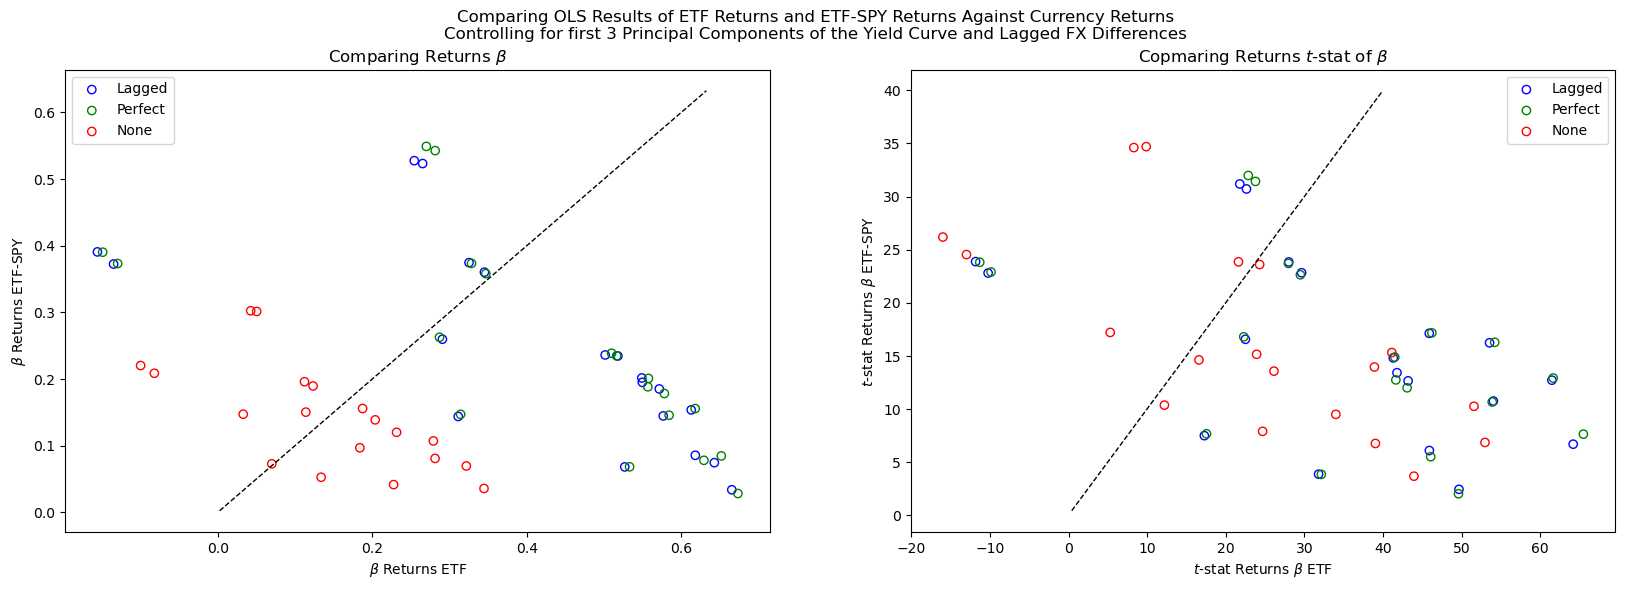

In [26]:
df_tmp = (df_pca_params
    .loc[lambda x: x.param_name.isin(["etf_rtn", "spread"])]
    .assign(ending = lambda x: x.group_var.str.split("-").str[-1]))

endings   = df_tmp.ending.drop_duplicates().sort_values().to_list()
params    = ["param_val", "tvalue"]
colors    = ["blue", "green", "red"]
fig, axes = plt.subplots(ncols = len(params), figsize = (20,6)) 

for param, ax in zip(params, axes.flatten()):
    
    for ending, color in zip(endings, colors): 

        df_plot = (df_tmp
            .loc[lambda x: x.ending == ending]
            .rename(columns = {"param_name": ""})
            .pivot(index = "group_var", columns = "", values = param))

        (ax.scatter(
            x          = df_plot.etf_rtn, 
            y          = df_plot.spread, 
            facecolors = "none",
            edgecolors = color,
            label      = RENAMER[ending]))

    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    # Range where y = x is actually inside both axes
    lower = max(xlim[0] * 0.9, ylim[0] * 1.1)
    upper = min(xlim[1] * 0.9, ylim[1] * 1.1)

    x = np.linspace(lower, upper, 500)

    ax.plot(
        x,
        x,
        color="black",
        linestyle="--",
        linewidth=1,
        zorder=1)


    ax.set_xlabel(x_renamer[param])
    ax.set_ylabel(y_renamer[param])
    ax.set_title(plot_renamer[param])
    ax.legend()

fig.suptitle("Comparing OLS Results of ETF Returns and ETF-SPY Returns Against Currency Returns\nControlling for first 3 Principal Components of the Yield Curve and Lagged FX Differences\n\n")
plt.show()

In [65]:
df_tmp_spread_params = (df_spread_params
    .loc[lambda x: x.param_name != "const"]
    .assign(etf_ticker = lambda x: x.group_var.str.split("-").str[0])
    .merge(right = df_ticker, how = "inner", on = ["etf_ticker"])
    [["param_val", "param_name", "group"]]
    .groupby(["param_name", "group"])
    .agg("mean")
    .reset_index()
    .assign(name = "spread_"))

In [66]:
df_tmp_pca_params = (df_pca_params
    .loc[lambda x: x.param_name.isin(["etf_rtn", "spread"])]
    .assign(etf_ticker = lambda x: x.group_var.str.split("-").str[0])
    .merge(right = df_ticker, how = "inner", on = ["etf_ticker"])
    [["param_val", "param_name", "group"]]
    .groupby(["group", "param_name"])
    .agg("mean")
    .reset_index()
    .assign(name = "pca"))

In [71]:
display(pd
    .concat([df_tmp_spread_params, df_tmp_pca_params])
    .replace(RENAMER)
    .replace({
        "etf_rtn": "ETF Return",
        "spread" : "ETF Spread Return"})
    .replace({
        "spread_": "Baseline",
        "pca"    : "PCs & Lagged"})
    .rename(columns = {
        "param_name": "Param",
        "name"      : "",
        "group"     : "Group"})
    .pivot(index = ["Param", "Group"], columns = "", values = "param_val"))

Baseline  PCs & Lagged
Param             Group                                   
ETF Return        EM Carry          0.296522      0.374648
                  G10 Carry         0.319654      0.296634
                  Illiquid Futures  0.314113      0.349685
                  Liquid Futures    0.320034      0.296634
ETF Spread Return EM Carry          0.108684      0.149966
                  G10 Carry         0.202651      0.241659
                  Illiquid Futures  0.147932      0.160164
                  Liquid Futures    0.189663      0.241659